In [9]:
# Grid sweep with oscillation detection for the Tyson-like 6-state ODE example
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import multiprocessing as mp
from multiprocessing import cpu_count
from concurrent.futures import ProcessPoolExecutor, as_completed
import platform
import psutil
import os

# Note: Multiprocessing on macOS with Jupyter notebooks is handled in the grid sweep cell
# The code will automatically detect if multiprocessing is available and fall back to serial if not

# ============================================================================
# === SETTABLE VARIABLES - MODIFY THESE TO CHANGE BEHAVIOR ===
# ============================================================================

# === Sampling mode ===
RANDOM = False  # If True, use random uniform sampling; if False, use grid sweep

# === Grid sweep settings ===
n_steps_per_param = 7  # Number of steps per parameter (creates n_steps_per_param^P grid points)
param_range_min = 0.1  # Minimum multiplier (0.1x standard)
param_range_max = 2.0  # Maximum multiplier (100x standard)
LOG = False  # If True, use logarithmic steps; if False, use linear steps

# === Simulation settings ===
simulation_time_start = 0.0  # Start time for simulation
simulation_time_end = 500.0  # End time for simulation
simulation_time_points = 501  # Number of time points in simulation

# === Oscillation detection settings ===
oscillation_require_peaks = 4  # Minimum number of peaks required for oscillation
oscillation_coarse_bins = 50  # Number of bins for coarse-graining
oscillation_cv_period_threshold = 0.15  # Coefficient of variation threshold for period regularity
oscillation_cv_amplitude_threshold = 0.15  # Coefficient of variation threshold for amplitude regularity
oscillation_amplitude_variation_threshold = 0.3  # Maximum allowed amplitude variation
oscillation_period_deviation_threshold = 0.2  # Maximum allowed period deviation from median

# === Phenotype storage settings ===
n_oscillation_phenotypes = 9  # Number of oscillation phenotypes to store and plot
n_nonoscillation_phenotypes = 9  # Number of non-oscillation phenotypes to store and plot

# === Progress reporting settings ===
progress_report_interval = 0.1  # Report progress every 10% (0.1 = 10%)

# === Multiprocessing settings ===
# Note: On macOS with Jupyter notebooks, multiprocessing may not work due to spawn method limitations
# The code will automatically fall back to serial processing if multiprocessing fails
USE_MULTIPROCESSING = True  # Enable multiprocessing for parallel grid sweep (will auto-disable if not supported)
BATCH_SIZE = 1000  # Number of parameter combinations to process per batch

# ============================================================================
# === BASE PARAMETERS (user provided) ===
# ============================================================================
p = {
    "k1_aa_over_CT": 0.015,
    "k2": 0.0,
    "k3_CT": 200.0,
    "k4": 180.0,
    "k4prime": 0.018,
    "k5_minusP": 0.0,
    "k6": 1.0,
    "k7": 0.6,
    "k8_minusP": 100.0,
    "k9": 50.0,
    "CT": 1.0
}

# We'll analyze these parameters (drop k2 and k5_minusP; add k8_minusP and k9)
param_names = [
    "k1_aa_over_CT",
    "k3_CT",
    "k4",
    "k4prime",
    "k6",
    "k7"
    #,"k8_minusP",
    #,"k9"
]
pvec = np.array([p[name] for name in param_names])
p_index = {name:i for i,name in enumerate(param_names)}
P = len(param_names)


# === model right-hand side and helper functions ===
CT = p["CT"]

def F_M(M, p):
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def dF_dM(M, p):
    # derivative of F_M wrt M
    return p["k4"] * 2.0 * (M / p["CT"]) * (1.0 / p["CT"])

def f_rhs(t, x, p):
    # x = [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p['CT']
    dC2 = p["k6"] * M - p["k8_minusP"] * C2 + p["k9"] * CP
    dCP = -k3 * CP * Y + p["k8_minusP"] * C2 - p["k9"] * CP
    dpM = k3 * CP * Y - pM * F_M(M, p) + p["k5_minusP"] * M
    dM  = pM * F_M(M, p) - p["k5_minusP"] * M - p["k6"] * M
    dY  = k1 - p["k2"] * Y - k3 * CP * Y
    dYP = p["k6"] * M - p["k7"] * YP
    return np.array([dC2, dCP, dpM, dM, dY, dYP])

# === Simulation and observation functions ===
def simulate_at_params(p_local, t_eval):
    """Simulate the ODE system with given parameters"""
    y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
    sol = solve_ivp(lambda tt, xx: f_rhs(tt, xx, p_local), (t_eval[0], t_eval[-1]), y0,
                    method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Integrator failed: " + sol.message)
    return sol.t, sol.y  # t, (6 x m)

def compute_obs(X):
    """Compute observables from state vector X: YT/CT and M/CT
    X can be a single state vector (6,) or full time series (6 x m)
    Returns arrays of YT/CT and M/CT for all time points
    """
    # Handle both 1D (single state) and 2D (time series) arrays
    if X.ndim == 1:
        C2, CP, pM, M, Y, YP = X
        YT = Y + YP + pM + M
        return YT / CT, M / CT
    else:
        # X is (6 x m) array
        C2, CP, pM, M, Y, YP = X
        YT = Y + YP + pM + M
        return YT / CT, M / CT

# === CPU OPTIMIZATION DETECTION ===
def detect_cpu_config():
    """Detect optimal CPU configuration for parallel processing"""
    cpu_count_total = cpu_count()
    cpu_info = platform.processor()
    
    # Check if this is an AMD/Radeon CPU
    is_amd = any(keyword in cpu_info.lower() for keyword in ['amd', 'radeon', 'ryzen', 'epyc', 'athlon'])
    
    if is_amd:
        # AMD CPUs often benefit from using physical cores only
        try:
            physical_cores = psutil.cpu_count(logical=False)
            logical_cores = psutil.cpu_count(logical=True)
            
            # For AMD, often best to use 75-85% of physical cores for compute-heavy tasks
            optimal_workers = max(1, int(physical_cores * 0.8)) if physical_cores else max(1, int(cpu_count_total * 0.7))
            
            print(f"🔧 AMD/Radeon CPU detected: {cpu_info}")
            print(f"   Physical cores: {physical_cores}, Logical cores: {logical_cores}")
            print(f"   Optimal workers for grid sweep: {optimal_workers}")
            
            return optimal_workers, True
        except:
            # Fallback if psutil fails
            optimal_workers = max(1, int(cpu_count_total * 0.7))
            print(f"🔧 AMD CPU detected (fallback): using {optimal_workers} workers")
            return optimal_workers, True
    else:
        # Non-AMD CPU: use standard approach
        optimal_workers = max(1, cpu_count_total - 1)
        print(f"🔧 Non-AMD CPU: using {optimal_workers} workers")
        return optimal_workers, False

OPTIMAL_WORKERS, IS_AMD_CPU = detect_cpu_config()
NUM_WORKERS = OPTIMAL_WORKERS if USE_MULTIPROCESSING else 1

# AMD/Radeon specific optimizations
if IS_AMD_CPU and USE_MULTIPROCESSING:
    os.environ['OMP_NUM_THREADS'] = str(NUM_WORKERS)
    os.environ['MKL_NUM_THREADS'] = str(NUM_WORKERS)
    os.environ['NUMEXPR_NUM_THREADS'] = str(NUM_WORKERS)



🔧 Non-AMD CPU: using 11 workers


In [2]:
# === Grid sweep setup (using settable variables from cell 0) ===
# Calculate grid parameters (log or linear based on LOG variable)
if LOG:
    # Logarithmic steps
    log_min = np.log(param_range_min)
    log_max = np.log(param_range_max)
    log_step_size = (log_max - log_min) / (n_steps_per_param - 1) if n_steps_per_param > 1 else 0
    step_type = "logarithmic"
else:
    # Linear steps
    linear_step_size = (param_range_max - param_range_min) / (n_steps_per_param - 1) if n_steps_per_param > 1 else 0
    step_type = "linear"

print(f"Grid sweep settings:")
print(f"  Parameters: {param_names}")
print(f"  Steps per parameter: {n_steps_per_param}")
print(f"  Total grid points: {n_steps_per_param ** len(param_names):,}")
print(f"  Range: {param_range_min}x to {param_range_max}x standard values")
print(f"  Step type: {step_type}")
if LOG:
    print(f"  Log step size: {log_step_size:.6f}")
else:
    print(f"  Linear step size: {linear_step_size:.6f}")
print(f"\nSimulation settings:")
print(f"  Time range: {simulation_time_start} to {simulation_time_end}")
print(f"  Time points: {simulation_time_points}")
print(f"\nOscillation detection settings:")
print(f"  Required peaks: {oscillation_require_peaks}")
print(f"  Coarse bins: {oscillation_coarse_bins}")
print(f"  CV thresholds: period={oscillation_cv_period_threshold}, amplitude={oscillation_cv_amplitude_threshold}")
print(f"\nMultiprocessing settings:")
print(f"  Use multiprocessing: {USE_MULTIPROCESSING}")
if USE_MULTIPROCESSING:
    print(f"  Number of workers: {NUM_WORKERS}")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  CPU type: {'AMD/Radeon optimized' if IS_AMD_CPU else 'Standard'}")


Grid sweep settings:
  Parameters: ['k1_aa_over_CT', 'k3_CT', 'k4', 'k4prime', 'k6', 'k7']
  Steps per parameter: 7
  Total grid points: 117,649
  Range: 0.1x to 2.0x standard values
  Step type: linear
  Linear step size: 0.316667

Simulation settings:
  Time range: 0.0 to 500.0
  Time points: 501

Oscillation detection settings:
  Required peaks: 4
  Coarse bins: 50
  CV thresholds: period=0.15, amplitude=0.15

Multiprocessing settings:
  Use multiprocessing: True
  Number of workers: 11
  Batch size: 1000
  CPU type: Standard


In [ ]:
# ----------------------------
# Worker function for parallel batch processing
# ----------------------------

def process_batch_worker(args):
    """Worker function for parallel grid sweep processing
    
    Args:
        args: tuple containing:
            - batch_combinations: list of parameter combination indices (tuples)
            - multipliers: array of multiplier values
            - param_names: list of parameter names
            - p_base: base parameter dictionary
            - t_eval: time evaluation array
            - n_oscillation_phenotypes: max oscillation phenotypes to store
            - n_nonoscillation_phenotypes: max non-oscillation phenotypes to store
            - oscillation_settings: dict with oscillation detection settings
            - YT_ref: reference YT/CT array
            - t_ref: reference time array
    
    Returns:
        dict with batch results
    """
    (batch_combinations, multipliers, param_names_worker, p_base, t_eval_worker, 
     n_osc_worker, n_nonosc_worker, osc_settings, YT_ref, t_ref, use_random, 
     param_range_min, param_range_max) = args
    
    # Import necessary functions (needed for multiprocessing)
    import numpy as np
    from scipy.integrate import solve_ivp
    import copy
    
    # Re-import oscillation detection functions (needed in worker process)
    from scipy.signal import find_peaks, savgol_filter
    
    def estimate_period_conservative_worker(time, signal, require_peaks, coarse_bins,
                                           cv_period_thresh, cv_amplitude_thresh,
                                           amplitude_variation_thresh, period_deviation_thresh):
        """Worker version of oscillation detection"""
        time = np.asarray(time)
        signal = np.asarray(signal)
        
        if len(signal) > 21:
            signal_smooth = savgol_filter(signal, 21, 3)
        else:
            signal_smooth = signal
        
        dynamic_prom = 0.1 * (np.max(signal_smooth) - np.min(signal_smooth))
        min_distance = len(time) // 50
        
        peaks, props = find_peaks(signal_smooth, 
                                prominence=dynamic_prom, 
                                distance=min_distance,
                                width=5)
        
        if len(peaks) < require_peaks:
            return None, (None, None)
        
        peak_times = time[peaks]
        periods = np.diff(peak_times)
        mean_period = np.mean(periods)
        
        if len(periods) < 3:
            return None, (None, None)
        
        cv_period = np.std(periods) / mean_period
        amplitudes = signal_smooth[peaks]
        cv_amplitude = np.std(amplitudes) / np.mean(amplitudes)
        
        if cv_period > cv_period_thresh or cv_amplitude > cv_amplitude_thresh:
            return None, (None, None)
        
        min_amp = np.min(amplitudes)
        max_amp = np.max(amplitudes)
        if (max_amp - min_amp) / max_amp > amplitude_variation_thresh:
            return None, (None, None)
        
        median_period = np.median(periods)
        if np.any(np.abs(periods - median_period) / median_period > period_deviation_thresh):
            return None, (None, None)
        
        if len(peaks) >= 4:
            mid_idx = len(peaks) // 2
            start_peak = peaks[mid_idx - 1]
            end_peak = peaks[mid_idx]
        else:
            start_peak = peaks[-2]
            end_peak = peaks[-1]
        
        mid_peak = start_peak
        half_period = 0.5 * mean_period
        t_start = time[mid_peak] - half_period
        t_end = time[mid_peak] + half_period
        t_start = max(time[0], t_start)
        t_end = min(time[-1], t_end)
        
        mask = (time >= t_start) & (time <= t_end)
        cycle_time = time[mask]
        cycle_signal = signal[mask]
        
        if len(cycle_time) < 10:
            return None, (None, None)
        
        coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
        coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)
        
        return mean_period, (coarse_time, coarse_signal)
    
    def is_oscillatory_worker(time, signal, require_peaks, coarse_bins,
                             cv_period_thresh, cv_amplitude_thresh,
                             amplitude_variation_thresh, period_deviation_thresh):
        """Worker version of is_oscillatory"""
        period, _ = estimate_period_conservative_worker(
            time, signal, require_peaks, coarse_bins,
            cv_period_thresh, cv_amplitude_thresh,
            amplitude_variation_thresh, period_deviation_thresh
        )
        return period is not None
    
    def f_rhs_worker(t, x, p_local):
        """Worker version of f_rhs"""
        C2, CP, pM, M, Y, YP = x
        k3 = p_local["k3_CT"] / p_local["CT"]
        k1 = p_local["k1_aa_over_CT"] * p_local['CT']
        dC2 = p_local["k6"] * M - p_local["k8_minusP"] * C2 + p_local["k9"] * CP
        dCP = -k3 * CP * Y + p_local["k8_minusP"] * C2 - p_local["k9"] * CP
        F_M_val = F_M_worker(M, p_local)
        dpM = k3 * CP * Y - pM * F_M_val + p_local["k5_minusP"] * M
        dM = pM * F_M_val - p_local["k5_minusP"] * M - p_local["k6"] * M
        dY = k1 - p_local["k2"] * Y - k3 * CP * Y
        dYP = p_local["k6"] * M - p_local["k7"] * YP
        return np.array([dC2, dCP, dpM, dM, dY, dYP])
    
    def F_M_worker(M, p_local):
        return p_local["k4prime"] + p_local["k4"] * (M / p_local["CT"])**2
    
    def simulate_at_params_worker(p_local, t_eval_local):
        """Worker version of simulate_at_params"""
        y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
        sol = solve_ivp(lambda tt, xx: f_rhs_worker(tt, xx, p_local), 
                       (t_eval_local[0], t_eval_local[-1]), y0,
                       method='BDF', t_eval=t_eval_local, rtol=1e-6, atol=1e-8)
        if not sol.success:
            raise RuntimeError("Integrator failed: " + sol.message)
        return sol.t, sol.y
    
    def compute_obs_worker(X, CT_local):
        """Worker version of compute_obs"""
        C2, CP, pM, M, Y, YP = X
        YT = Y + YP + pM + M
        return YT / CT_local, M / CT_local
    
    # Initialize batch results
    batch_results = {
        'oscillation_count': 0,
        'non_oscillation_count': 0,
        'oscillation_phenotypes': [],
        'non_oscillation_phenotypes': [],
        'all_results': []
    }
    
    # Process each combination in the batch
    for combo_data in batch_combinations:
        try:
            # Create parameter dictionary for this combination
            p_local = copy.deepcopy(p_base)
            params_dict = {}
            
            if use_random:
                # combo_data is a random parameter vector (already in parameter space)
                # Scale from [0,1] to [param_range_min, param_range_max] * base
                for i, param_name in enumerate(param_names_worker):
                    # combo_data[i] is in [0,1], scale to multiplier range
                    u_val = combo_data[i]
                    multiplier = param_range_min + u_val * (param_range_max - param_range_min)
                    p_local[param_name] = p_base[param_name] * multiplier
                    params_dict[param_name] = p_local[param_name]
            else:
                # combo_data is a tuple of indices into multipliers array
                combo_idx = combo_data
                for i, param_name in enumerate(param_names_worker):
                    multiplier = multipliers[combo_idx[i]]
                    p_local[param_name] = p_base[param_name] * multiplier
                    params_dict[param_name] = p_local[param_name]
            
            # Simulate
            t, y = simulate_at_params_worker(p_local, t_eval_worker)
            YT, M = compute_obs_worker(y, p_base["CT"])
            
            # Check for oscillation
            is_osc = is_oscillatory_worker(
                t, YT,
                osc_settings['require_peaks'],
                osc_settings['coarse_bins'],
                osc_settings['cv_period_threshold'],
                osc_settings['cv_amplitude_threshold'],
                osc_settings['amplitude_variation_threshold'],
                osc_settings['period_deviation_threshold']
            )
            
            # Compute square integral difference for YT/CT relative to reference
            # Interpolate reference to match current time points
            YT_ref_interp = np.interp(t, t_ref, YT_ref)
            # Compute squared difference
            diff_YT_sq = (YT - YT_ref_interp)**2
            # Integrate using np.trapezoid
            square_integral_diff_YT = np.trapezoid(diff_YT_sq, t)
            
            # Store result
            result = {
                'params': params_dict,
                'is_oscillatory': is_osc,
                'YT': YT,
                'M': M,
                't': t,
                'square_integral_diff_YT': square_integral_diff_YT
            }
            batch_results['all_results'].append(result)
            
            if is_osc:
                batch_results['oscillation_count'] += 1
                if len(batch_results['oscillation_phenotypes']) < n_osc_worker:
                    batch_results['oscillation_phenotypes'].append(result)
            else:
                batch_results['non_oscillation_count'] += 1
                if len(batch_results['non_oscillation_phenotypes']) < n_nonosc_worker:
                    batch_results['non_oscillation_phenotypes'].append(result)
                    
        except Exception as e:
            # Handle errors (divergent solutions, etc.)
            result = {
                'params': params_dict if 'params_dict' in locals() else {},
                'is_oscillatory': False,
                'YT': None,
                'M': None,
                't': None,
                'square_integral_diff_YT': None,
                'error': str(e)
            }
            batch_results['all_results'].append(result)
            batch_results['non_oscillation_count'] += 1
    
    return batch_results

print("✓ Worker function for batch processing defined")


✓ Worker function for batch processing defined


In [4]:
# ----------------------------
# Oscillation detection function (from ChicoOscillationBiologicalFenotype.ipynb)
# ----------------------------

from scipy.signal import find_peaks, savgol_filter

def estimate_period_conservative(time, signal, require_peaks=None, center_on_peak=True, coarse_bins=None):
    """Conservative peak detection with strict regularity requirements"""
    # Use global settings if not provided
    if require_peaks is None:
        require_peaks = oscillation_require_peaks
    if coarse_bins is None:
        coarse_bins = oscillation_coarse_bins
    time = np.asarray(time)
    signal = np.asarray(signal)

    # Apply smoothing
    if len(signal) > 21:
        signal_smooth = savgol_filter(signal, 21, 3)
    else:
        signal_smooth = signal

    # Conservative peak detection
    dynamic_prom = 0.1 * (np.max(signal_smooth) - np.min(signal_smooth))  # Higher prominence
    min_distance = len(time) // 50  # Larger minimum distance
    
    peaks, props = find_peaks(signal_smooth, 
                            prominence=dynamic_prom, 
                            distance=min_distance,
                            width=5)  # Require wider peaks

    if len(peaks) < require_peaks:
        return None, (None, None)

    # Strict regularity assessment
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    mean_period = np.mean(periods)
    
    if len(periods) < 3:  # Require more periods
        return None, (None, None)

    # Very strict thresholds
    cv_period = np.std(periods) / mean_period
    amplitudes = signal_smooth[peaks]
    cv_amplitude = np.std(amplitudes) / np.mean(amplitudes)

    if cv_period > oscillation_cv_period_threshold or cv_amplitude > oscillation_cv_amplitude_threshold:
        return None, (None, None)
    
    # Additional quality checks
    # Check that peaks are well-separated in amplitude
    min_amp = np.min(amplitudes)
    max_amp = np.max(amplitudes)
    if (max_amp - min_amp) / max_amp > oscillation_amplitude_variation_threshold:
        return None, (None, None)
    
    # Check period consistency
    median_period = np.median(periods)
    if np.any(np.abs(periods - median_period) / median_period > oscillation_period_deviation_threshold):
        return None, (None, None)

    # Extract most stable cycle (middle one)
    if len(peaks) >= 4:
        mid_idx = len(peaks) // 2
        start_peak = peaks[mid_idx - 1]
        end_peak = peaks[mid_idx]
    else:
        start_peak = peaks[-2]
        end_peak = peaks[-1]
    
    if center_on_peak:
        mid_peak = start_peak
        half_period = 0.5 * mean_period
        t_start = time[mid_peak] - half_period 
        t_end = time[mid_peak] + half_period 
        t_start = max(time[0], t_start)
        t_end = min(time[-1], t_end)
    else:
        t_start, t_end = time[start_peak], time[end_peak]

    mask = (time >= t_start) & (time <= t_end)
    cycle_time = time[mask]
    cycle_signal = signal[mask]

    if len(cycle_time) < 10:  # Require more points
        return None, (None, None)

    coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
    coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)

    return mean_period, (coarse_time, coarse_signal)

def is_oscillatory(time, signal):
    """Check if a signal is oscillatory using conservative peak detection"""
    period, _ = estimate_period_conservative(time, signal, require_peaks=oscillation_require_peaks)
    return period is not None

print("✓ Oscillation detection function loaded")

✓ Oscillation detection function loaded


In [5]:
# ----------------------------
# Full grid sweep with oscillation detection
# ----------------------------

import copy
from itertools import product
try:
    from tqdm import tqdm
except ImportError:
    # Fallback if tqdm is not available
    def tqdm(iterable, desc=""):
        return iterable

# Generate parameter combinations based on RANDOM flag
if RANDOM:
    # Random uniform sampling: generate 6^n_steps_per_param random points
    # Each point is uniform in [0,1] for each coordinate
    total_combinations = 6 ** n_steps_per_param
    print(f"\nGenerating random uniform parameter samples...")
    print(f"Total random points to generate: {total_combinations:,}")
    print(f"  (6^{n_steps_per_param} = {total_combinations:,})")
    print(f"  Each parameter sampled uniformly in [{param_range_min}, {param_range_max}]x base value")
    
    # Generate random points: each is a vector of len(param_names) values in [0,1]
    np.random.seed(42)  # For reproducibility
    param_combinations = []
    for _ in range(total_combinations):
        # Generate random vector in [0,1] for each parameter
        random_vec = np.random.uniform(0, 1, size=len(param_names))
        param_combinations.append(random_vec)
    
    # Dummy multipliers for compatibility (not used in random mode)
    multipliers = np.array([1.0])
else:
    # Grid sweep: create grid for each parameter (log or linear based on LOG variable)
    if LOG:
        # Logarithmic steps: create in log space, then convert to linear
        log_values = np.linspace(log_min, log_max, n_steps_per_param)
        multipliers = np.exp(log_values)  # Convert to linear space
    else:
        # Linear steps: create directly in linear space
        multipliers = np.linspace(param_range_min, param_range_max, n_steps_per_param)

    print(f"\nGenerating parameter grid ({'logarithmic' if LOG else 'linear'} steps)...")
    print(f"Multipliers: {multipliers}")

    # Generate all parameter combinations
    param_combinations = list(product(range(n_steps_per_param), repeat=len(param_names)))
    total_combinations = len(param_combinations)
    print(f"Total combinations to test: {total_combinations:,}")

# Storage for results
oscillation_results = []  # List of (params_dict, is_oscillatory, YT, M, t)
oscillation_count = 0
non_oscillation_count = 0

# Storage for phenotypes
oscillation_phenotypes = []
non_oscillation_phenotypes = []

# Time grid for simulation (using settable variables)
t_eval = np.linspace(simulation_time_start, simulation_time_end, simulation_time_points)

print(f"\n{'='*60}")
if RANDOM:
    print(f"Starting random uniform sampling...")
else:
    print(f"Starting grid sweep...")
print(f"{'='*60}")
print(f"Total combinations to test: {total_combinations:,}")
if USE_MULTIPROCESSING:
    print(f"🚀 Using parallel processing: {NUM_WORKERS} workers")
    print(f"📦 Batch size: {BATCH_SIZE} combinations per batch")
else:
    print(f"🔄 Using serial processing (multiprocessing disabled)")
print(f"Progress will be reported every {progress_report_interval*100:.0f}% completion")
print(f"{'='*60}\n")

import time
start_time = time.time()

# Prepare oscillation settings dict for workers
oscillation_settings = {
    'require_peaks': oscillation_require_peaks,
    'coarse_bins': oscillation_coarse_bins,
    'cv_period_threshold': oscillation_cv_period_threshold,
    'cv_amplitude_threshold': oscillation_cv_amplitude_threshold,
    'amplitude_variation_threshold': oscillation_amplitude_variation_threshold,
    'period_deviation_threshold': oscillation_period_deviation_threshold
}

# Precompute reference YT/CT using base parameters
print("Computing reference simulation with base parameters...")
t_ref, y_ref = simulate_at_params(p, t_eval)
YT_ref, M_ref = compute_obs(y_ref)
print("✓ Reference simulation complete\n")

# Split combinations into batches
num_batches = (total_combinations + BATCH_SIZE - 1) // BATCH_SIZE
batches = []
for i in range(num_batches):
    batch_start = i * BATCH_SIZE
    batch_end = min(batch_start + BATCH_SIZE, total_combinations)
    batch_combinations = param_combinations[batch_start:batch_end]
    batches.append((
        batch_combinations,
        multipliers,
        param_names,
        p,
        t_eval,
        n_oscillation_phenotypes,
        n_nonoscillation_phenotypes,
        oscillation_settings,
        YT_ref,
        t_ref,
        RANDOM,  # Pass RANDOM flag to worker
        param_range_min,  # For random sampling scaling
        param_range_max   # For random sampling scaling
    ))

print(f"📋 Created {num_batches} batches for processing\n")

# Process batches in parallel or serial
all_batch_results = []

# Test if multiprocessing will work (check if function can be pickled)
# On macOS with Jupyter, spawn method can't pickle functions from notebook cells
multiprocessing_works = False
if USE_MULTIPROCESSING and NUM_WORKERS > 1:
    # Check if we're on macOS - multiprocessing often fails in Jupyter notebooks there
    if platform.system() == 'Darwin':
        # Try to use fork method if available
        try:
            mp.set_start_method('fork', force=True)
            multiprocessing_works = True
        except (RuntimeError, ValueError):
            # Fork not available, spawn will likely fail - disable multiprocessing
            print(f"⚠️  Multiprocessing not available on macOS with spawn method in Jupyter notebooks")
            print(f"   Using serial processing instead...")
            multiprocessing_works = False
    else:
        # On Linux/Windows, try to test if it works
        try:
            import pickle
            test_batch = batches[0] if batches else None
            if test_batch:
                pickle.dumps(process_batch_worker)
                pickle.dumps(test_batch)
                multiprocessing_works = True
        except Exception as e:
            print(f"⚠️  Multiprocessing test failed: {e}")
            print(f"   Falling back to serial processing...")
            multiprocessing_works = False

if multiprocessing_works:
    if RANDOM:
        print(f"🔄 Running parallel random sampling with ProcessPoolExecutor...")
    else:
        print(f"🔄 Running parallel grid sweep with ProcessPoolExecutor...")
    
    try:
        with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
            # Submit all batches
            future_to_batch = {executor.submit(process_batch_worker, batch_args): i 
                              for i, batch_args in enumerate(batches)}
            
            completed_batches = 0
            
            # Process completed batches
            for future in as_completed(future_to_batch):
                batch_idx = future_to_batch[future]
                
                try:
                    batch_result = future.result()
                    all_batch_results.append(batch_result)
                    completed_batches += 1
                    
                    # Progress update
                    total_processed = sum(len(r['all_results']) for r in all_batch_results)
                    total_osc = sum(r['oscillation_count'] for r in all_batch_results)
                    total_nonosc = sum(r['non_oscillation_count'] for r in all_batch_results)
                    elapsed = time.time() - start_time
                    rate = total_processed / elapsed if elapsed > 0 else 0
                    progress = completed_batches / num_batches * 100
                    
                    # Report progress at specified intervals
                    if completed_batches % max(1, int(num_batches * progress_report_interval)) == 0 or completed_batches == num_batches:
                        print(f"  Progress: {progress:.1f}% ({completed_batches}/{num_batches} batches) | "
                              f"Processed: {total_processed:,}/{total_combinations:,} | "
                              f"Oscillations: {total_osc} | Non-oscillations: {total_nonosc} | "
                              f"Rate: {rate:.1f} combos/s")
                    
                except Exception as e:
                    print(f"❌ Batch {batch_idx} failed: {e}")
                    # Add empty result to maintain count
                    all_batch_results.append({
                        'oscillation_count': 0,
                        'non_oscillation_count': 0,
                        'oscillation_phenotypes': [],
                        'non_oscillation_phenotypes': [],
                        'all_results': []
                    })
                    completed_batches += 1
    except Exception as e:
        print(f"❌ Multiprocessing failed: {e}")
        print(f"   Falling back to serial processing...")
        multiprocessing_works = False

if not multiprocessing_works:
    if RANDOM:
        print(f"🔄 Running serial random sampling...")
    else:
        print(f"🔄 Running serial grid sweep...")
    for i, batch_args in enumerate(batches):
        batch_result = process_batch_worker(batch_args)
        all_batch_results.append(batch_result)
        
        # Progress update
        total_processed = sum(len(r['all_results']) for r in all_batch_results)
        total_osc = sum(r['oscillation_count'] for r in all_batch_results)
        total_nonosc = sum(r['non_oscillation_count'] for r in all_batch_results)
        elapsed = time.time() - start_time
        rate = total_processed / elapsed if elapsed > 0 else 0
        progress = (i + 1) / num_batches * 100
        
        if (i + 1) % max(1, int(num_batches * progress_report_interval)) == 0 or (i + 1) == num_batches:
            print(f"  Progress: {progress:.1f}% ({i+1}/{num_batches} batches) | "
                  f"Processed: {total_processed:,}/{total_combinations:,} | "
                  f"Oscillations: {total_osc} | Non-oscillations: {total_nonosc} | "
                  f"Rate: {rate:.1f} combos/s")

# Merge results from all batches
print(f"\n📊 Merging results from {len(all_batch_results)} batches...")
oscillation_results = []
oscillation_count = 0
non_oscillation_count = 0
oscillation_phenotypes = []
non_oscillation_phenotypes = []

for batch_result in all_batch_results:
    oscillation_results.extend(batch_result['all_results'])
    oscillation_count += batch_result['oscillation_count']
    non_oscillation_count += batch_result['non_oscillation_count']
    
    # Collect phenotypes (up to limits)
    for pheno in batch_result['oscillation_phenotypes']:
        if len(oscillation_phenotypes) < n_oscillation_phenotypes:
            oscillation_phenotypes.append(pheno)
    
    for pheno in batch_result['non_oscillation_phenotypes']:
        if len(non_oscillation_phenotypes) < n_nonoscillation_phenotypes:
            non_oscillation_phenotypes.append(pheno)

processing_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"Grid sweep completed!")
print(f"  ⏱️  Total time: {processing_time:.1f}s ({processing_time/60:.1f}m)")
print(f"  Total tested: {total_combinations:,}")
print(f"  Oscillatory: {oscillation_count} ({100*oscillation_count/total_combinations:.2f}%)")
print(f"  Non-oscillatory: {non_oscillation_count} ({100*non_oscillation_count/total_combinations:.2f}%)")
print(f"  Oscillation phenotypes stored: {len(oscillation_phenotypes)}")
print(f"  Non-oscillation phenotypes stored: {len(non_oscillation_phenotypes)}")
if processing_time > 0:
    print(f"  ⚡ Processing rate: {total_combinations/processing_time:.1f} combos/s")
print(f"{'='*60}\n")



Generating parameter grid (linear steps)...
Multipliers: [0.1        0.41666667 0.73333333 1.05       1.36666667 1.68333333
 2.        ]
Total combinations to test: 117,649

Starting grid sweep...
Total combinations to test: 117,649
🚀 Using parallel processing: 11 workers
📦 Batch size: 1000 combinations per batch
Progress will be reported every 10% completion

Computing reference simulation with base parameters...
✓ Reference simulation complete

📋 Created 118 batches for processing

🔄 Running parallel grid sweep with ProcessPoolExecutor...


/tmp/ipykernel_547390/1622134987.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  square_integral_diff_YT = np.trapz(diff_YT_sq, t)
/tmp/ipykernel_547390/1622134987.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  square_integral_diff_YT = np.trapz(diff_YT_sq, t)
/tmp/ipykernel_547390/1622134987.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  square_integral_diff_YT = np.trapz(diff_YT_sq, t)
/tmp/ipykernel_547390/1622134987.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  square_integral_diff_YT = np.trapz(diff_YT_sq, t)
/tmp/ipykernel_547390/1622134987.py:194: DeprecationWarning: `trapz` is deprecated. 

  Progress: 9.3% (11/118 batches) | Processed: 11,000/117,649 | Oscillations: 93 | Non-oscillations: 10907 | Rate: 37.4 combos/s
  Progress: 18.6% (22/118 batches) | Processed: 22,000/117,649 | Oscillations: 818 | Non-oscillations: 21182 | Rate: 33.5 combos/s
  Progress: 28.0% (33/118 batches) | Processed: 33,000/117,649 | Oscillations: 2355 | Non-oscillations: 30645 | Rate: 35.5 combos/s
  Progress: 37.3% (44/118 batches) | Processed: 44,000/117,649 | Oscillations: 5627 | Non-oscillations: 38373 | Rate: 33.3 combos/s
  Progress: 46.6% (55/118 batches) | Processed: 55,000/117,649 | Oscillations: 9515 | Non-oscillations: 45485 | Rate: 30.1 combos/s
  Progress: 55.9% (66/118 batches) | Processed: 66,000/117,649 | Oscillations: 14019 | Non-oscillations: 51981 | Rate: 28.3 combos/s
  Progress: 65.3% (77/118 batches) | Processed: 77,000/117,649 | Oscillations: 18868 | Non-oscillations: 58132 | Rate: 25.9 combos/s
  Progress: 74.6% (88/118 batches) | Processed: 88,000/117,649 | Oscillations:

CUMULATIVE DISTRIBUTION OF SQUARE INTEGRAL DIFFERENCES

Total valid square integral differences: 117,649
  Min: 2.276405
  Max: 34120.305144
  Mean: 1092.008925
  Median: 13.667324

Thresholds: 1 to 51
Number of thresholds: 51


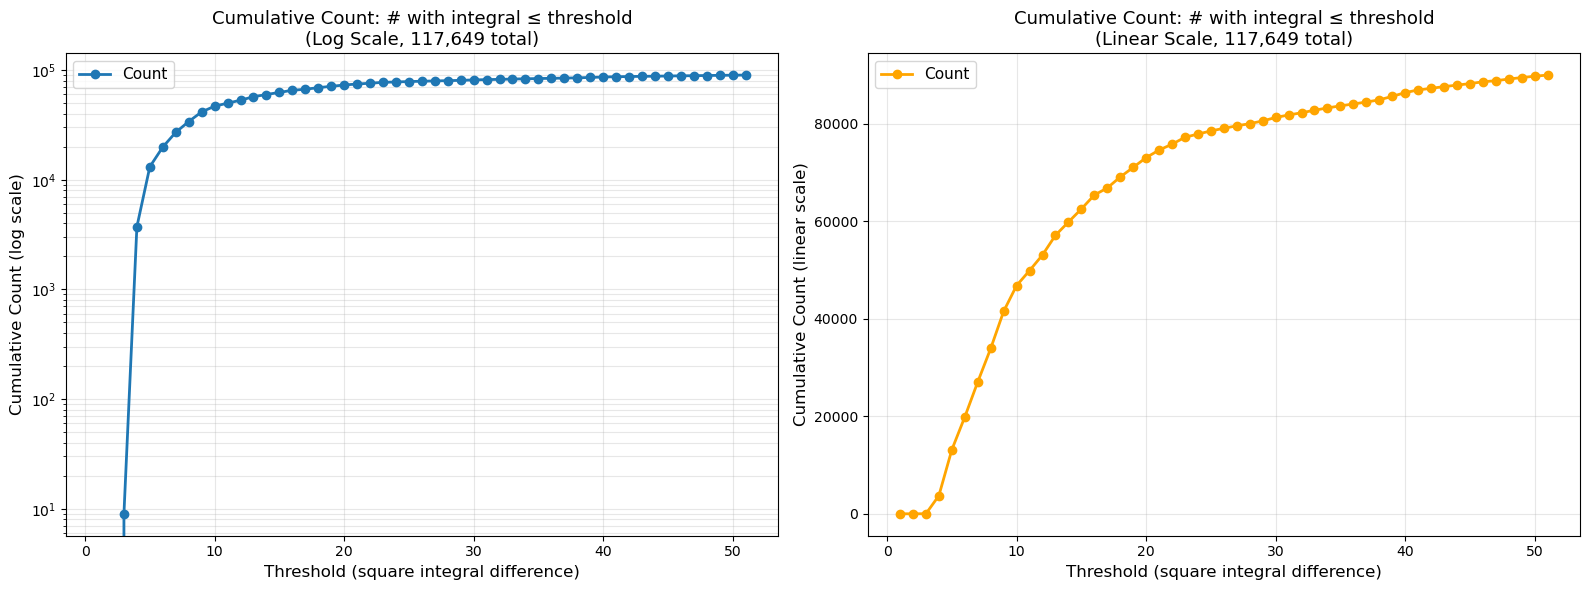

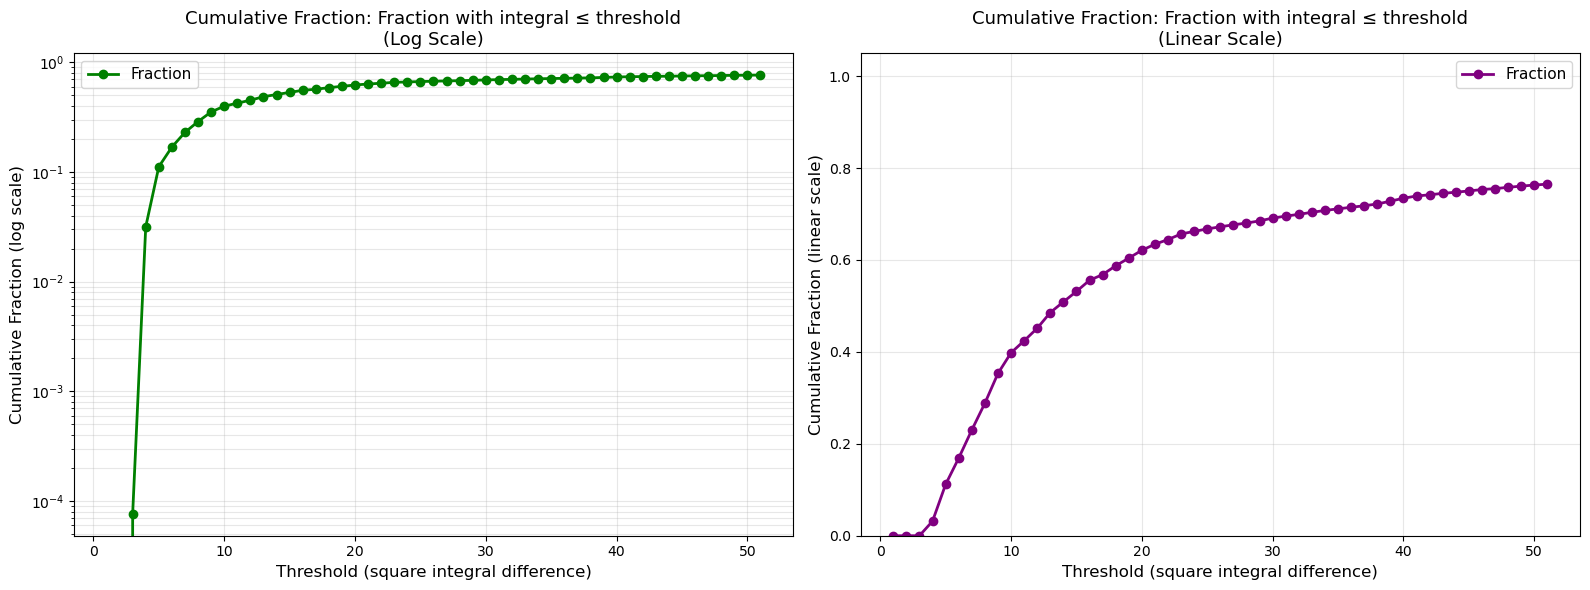


CUMULATIVE STATISTICS

Fraction of parameter combinations with integral ≤ threshold:
  ≤   1:      0 (  0.00%)
  ≤   2:      0 (  0.00%)
  ≤   3:      9 (  0.01%)
  ≤   4:  3,725 (  3.17%)
  ≤   5: 13,136 ( 11.17%)
  ≤   6: 19,860 ( 16.88%)
  ≤   7: 27,047 ( 22.99%)
  ≤   8: 33,913 ( 28.83%)
  ≤   9: 41,531 ( 35.30%)
  ≤  10: 46,823 ( 39.80%)
  ...
  ≤  51: 89,999 ( 76.50%)

Plots saved:
  - cumulative_square_integral_distribution.png (counts)
  - cumulative_square_integral_fraction.png (fractions)


In [11]:
# ----------------------------
# Cumulative distribution of square integral differences
# ----------------------------

print("="*60)
print("CUMULATIVE DISTRIBUTION OF SQUARE INTEGRAL DIFFERENCES")
print("="*60)

# Extract all square integral differences (filter out None values)
square_integrals = []
for result in oscillation_results:
    if result.get('square_integral_diff_YT') is not None:
        square_integrals.append(result['square_integral_diff_YT'])

square_integrals = np.array(square_integrals)
total_valid = len(square_integrals)

print(f"\nTotal valid square integral differences: {total_valid:,}")
if total_valid > 0:
    print(f"  Min: {square_integrals.min():.6f}")
    print(f"  Max: {square_integrals.max():.6f}")
    print(f"  Mean: {square_integrals.mean():.6f}")
    print(f"  Median: {np.median(square_integrals):.6f}")
    
    # Create thresholds: 1, 2, 3, ... up to max (rounded up)
    max_threshold = 51
    thresholds = np.arange(1, max_threshold + 1)
    
    # Count how many have square_integral_diff_YT <= each threshold
    cumulative_counts = []
    cumulative_fractions = []
    
    for threshold in thresholds:
        count = np.sum(square_integrals <= threshold)
        fraction = count / total_valid
        cumulative_counts.append(count)
        cumulative_fractions.append(fraction)
    
    cumulative_counts = np.array(cumulative_counts)
    cumulative_fractions = np.array(cumulative_fractions)
    
    print(f"\nThresholds: {thresholds[0]} to {thresholds[-1]}")
    print(f"Number of thresholds: {len(thresholds)}")
    
    # Plot cumulative distribution: side by side log and linear
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Log scale
    ax1.semilogy(thresholds, cumulative_counts, marker='o', linewidth=2, markersize=6, label='Count')
    ax1.set_xlabel('Threshold (square integral difference)', fontsize=12)
    ax1.set_ylabel('Cumulative Count (log scale)', fontsize=12)
    ax1.set_title(f'Cumulative Count: # with integral ≤ threshold\n(Log Scale, {total_valid:,} total)', fontsize=13)
    ax1.grid(True, alpha=0.3, which='both')
    ax1.legend(fontsize=11)
    
    # Right plot: Linear scale
    ax2.plot(thresholds, cumulative_counts, marker='o', linewidth=2, markersize=6, label='Count', color='orange')
    ax2.set_xlabel('Threshold (square integral difference)', fontsize=12)
    ax2.set_ylabel('Cumulative Count (linear scale)', fontsize=12)
    ax2.set_title(f'Cumulative Count: # with integral ≤ threshold\n(Linear Scale, {total_valid:,} total)', fontsize=13)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)
    
    plt.tight_layout()
    plt.savefig('cumulative_square_integral_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Also plot cumulative fraction (percentage)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Log scale (fraction)
    ax1.semilogy(thresholds, cumulative_fractions, marker='o', linewidth=2, markersize=6, label='Fraction', color='green')
    ax1.set_xlabel('Threshold (square integral difference)', fontsize=12)
    ax1.set_ylabel('Cumulative Fraction (log scale)', fontsize=12)
    ax1.set_title(f'Cumulative Fraction: Fraction with integral ≤ threshold\n(Log Scale)', fontsize=13)
    ax1.grid(True, alpha=0.3, which='both')
    ax1.legend(fontsize=11)
    
    # Right plot: Linear scale (fraction)
    ax2.plot(thresholds, cumulative_fractions, marker='o', linewidth=2, markersize=6, label='Fraction', color='purple')
    ax2.set_xlabel('Threshold (square integral difference)', fontsize=12)
    ax2.set_ylabel('Cumulative Fraction (linear scale)', fontsize=12)
    ax2.set_title(f'Cumulative Fraction: Fraction with integral ≤ threshold\n(Linear Scale)', fontsize=13)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)
    ax2.set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.savefig('cumulative_square_integral_fraction.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print some statistics
    print(f"\n{'='*60}")
    print("CUMULATIVE STATISTICS")
    print(f"{'='*60}")
    print(f"\nFraction of parameter combinations with integral ≤ threshold:")
    for i, threshold in enumerate(thresholds[:10]):  # Show first 10
        print(f"  ≤ {threshold:3d}: {cumulative_counts[i]:6,} ({cumulative_fractions[i]*100:6.2f}%)")
    if len(thresholds) > 10:
        print(f"  ...")
        print(f"  ≤ {thresholds[-1]:3d}: {cumulative_counts[-1]:6,} ({cumulative_fractions[-1]*100:6.2f}%)")
    
    print(f"\nPlots saved:")
    print(f"  - cumulative_square_integral_distribution.png (counts)")
    print(f"  - cumulative_square_integral_fraction.png (fractions)")
else:
    print("\nNo valid square integral differences found in results.")


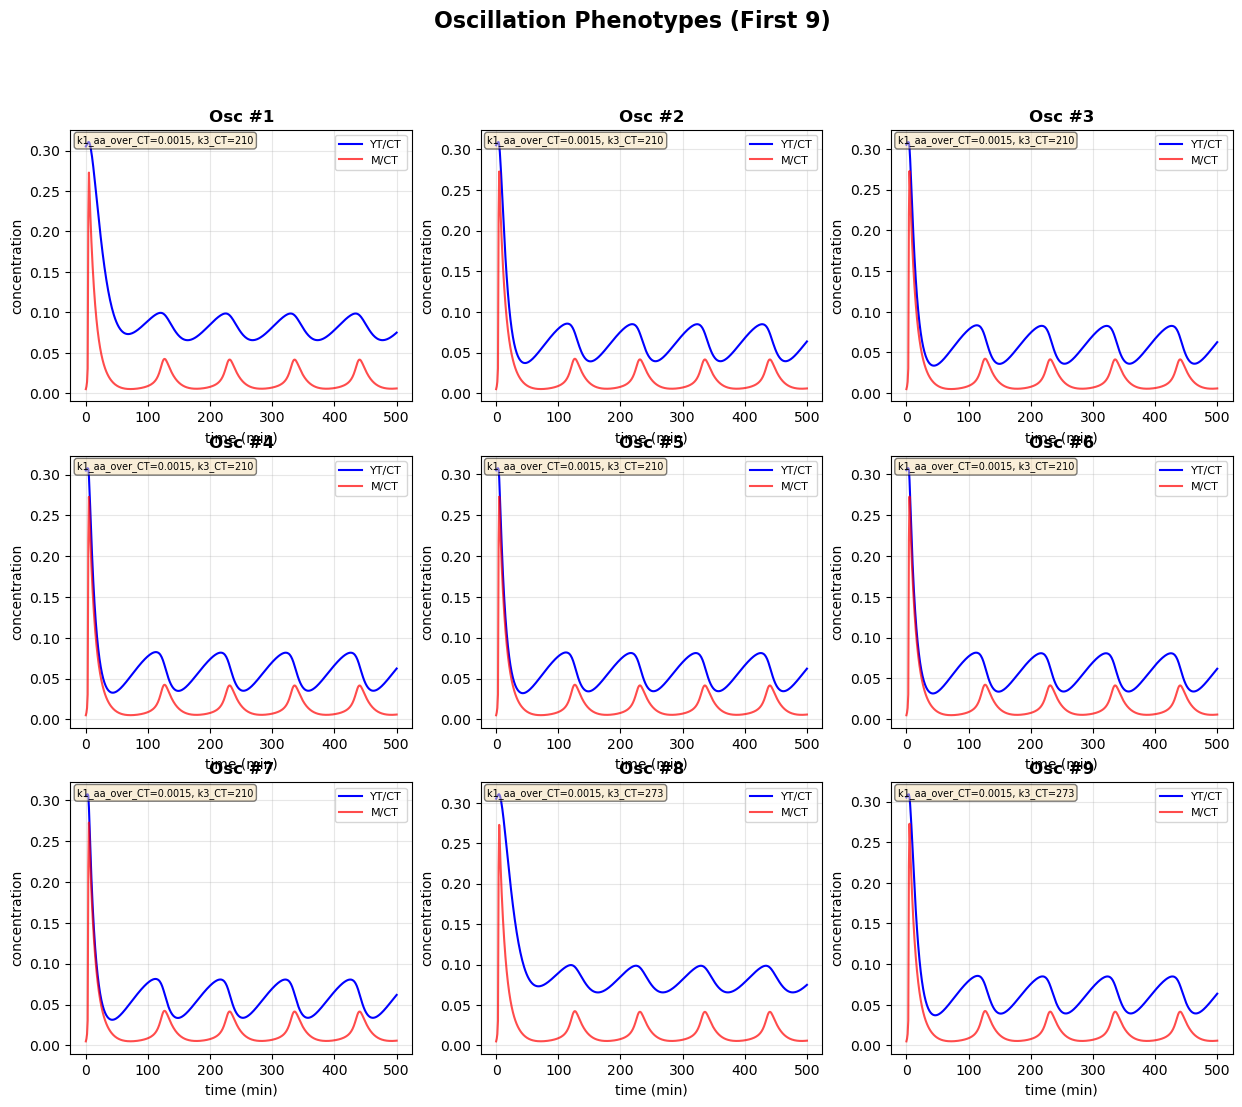

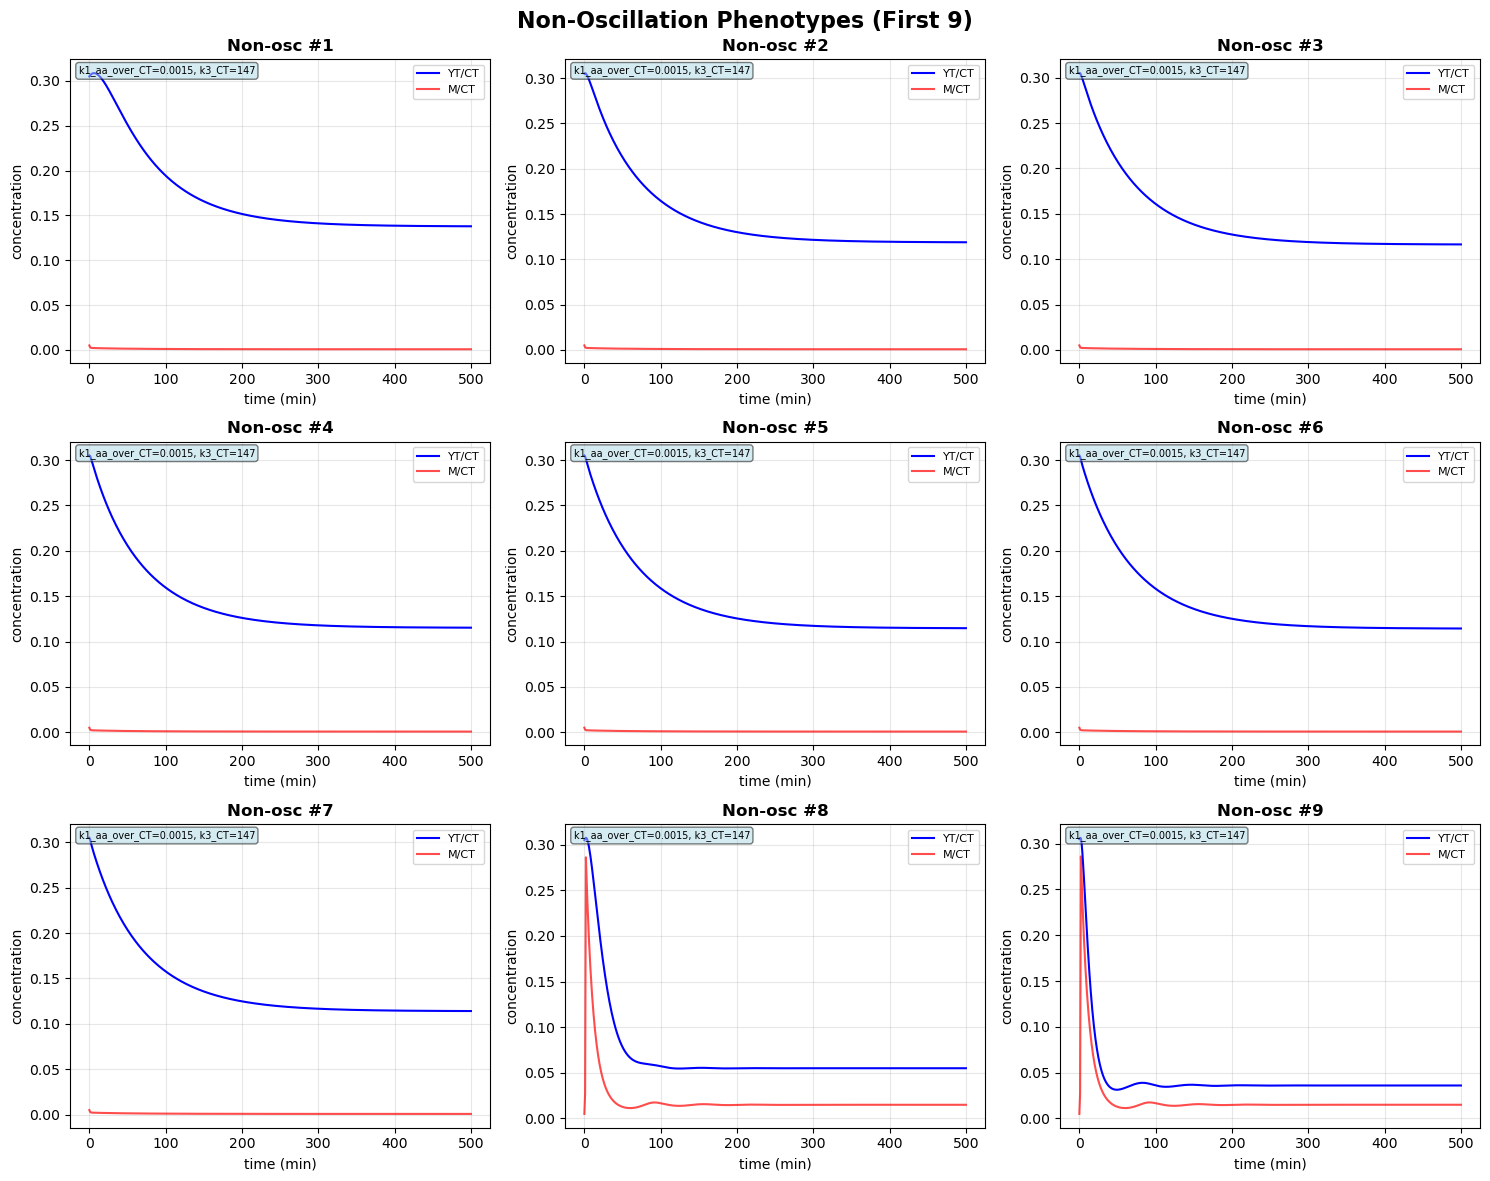

Plotted 9 oscillation phenotypes
Plotted 9 non-oscillation phenotypes


In [6]:
# ----------------------------
# Plot oscillation and non-oscillation phenotypes
# ----------------------------

# Create 2 3x3 plots: one for oscillations, one for non-oscillations
n_rows = int(np.ceil(np.sqrt(n_oscillation_phenotypes)))
n_cols = int(np.ceil(n_oscillation_phenotypes / n_rows))
fig_osc, axes_osc = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
fig_osc.suptitle(f'Oscillation Phenotypes (First {n_oscillation_phenotypes})', fontsize=16, fontweight='bold')
if n_oscillation_phenotypes == 1:
    axes_osc = np.array([axes_osc])
axes_osc = axes_osc.flatten()

n_rows_non = int(np.ceil(np.sqrt(n_nonoscillation_phenotypes)))
n_cols_non = int(np.ceil(n_nonoscillation_phenotypes / n_rows_non))
fig_nonosc, axes_nonosc = plt.subplots(n_rows_non, n_cols_non, figsize=(5*n_cols_non, 4*n_rows_non))
fig_nonosc.suptitle(f'Non-Oscillation Phenotypes (First {n_nonoscillation_phenotypes})', fontsize=16, fontweight='bold')
if n_nonoscillation_phenotypes == 1:
    axes_nonosc = np.array([axes_nonosc])
axes_nonosc = axes_nonosc.flatten()

# Plot oscillation phenotypes
for idx, result in enumerate(oscillation_phenotypes):
    ax = axes_osc[idx]
    
    if result['YT'] is not None and result['t'] is not None:
        ax.plot(result['t'], result['YT'], 'b-', lw=1.5, label='YT/CT')
        ax.plot(result['t'], result['M'], 'r-', lw=1.5, label='M/CT', alpha=0.7)
        ax.set_xlabel('time (min)')
        ax.set_ylabel('concentration')
        ax.set_title(f'Osc #{idx+1}', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Add parameter info as text
        param_str = ', '.join([f"{name}={result['params'][name]:.3g}" 
                               for name in param_names[:2]])  # Show first 2 params
        ax.text(0.02, 0.98, param_str, transform=ax.transAxes, 
                fontsize=7, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
                ha='center', va='center', fontsize=12)
        ax.set_title(f'Osc #{idx+1}', fontweight='bold')

# Hide unused subplots for oscillations
for idx in range(len(oscillation_phenotypes), len(axes_osc)):
    axes_osc[idx].axis('off')

# Plot non-oscillation phenotypes
for idx, result in enumerate(non_oscillation_phenotypes):
    ax = axes_nonosc[idx]
    
    if result['YT'] is not None and result['t'] is not None:
        ax.plot(result['t'], result['YT'], 'b-', lw=1.5, label='YT/CT')
        ax.plot(result['t'], result['M'], 'r-', lw=1.5, label='M/CT', alpha=0.7)
        ax.set_xlabel('time (min)')
        ax.set_ylabel('concentration')
        ax.set_title(f'Non-osc #{idx+1}', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Add parameter info as text
        param_str = ', '.join([f"{name}={result['params'][name]:.3g}" 
                               for name in param_names[:2]])  # Show first 2 params
        ax.text(0.02, 0.98, param_str, transform=ax.transAxes, 
                fontsize=7, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    else:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
                ha='center', va='center', fontsize=12)
        ax.set_title(f'Non-osc #{idx+1}', fontweight='bold')

# Hide unused subplots for non-oscillations
for idx in range(len(non_oscillation_phenotypes), len(axes_nonosc)):
    axes_nonosc[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Plotted {len(oscillation_phenotypes)} oscillation phenotypes")
print(f"Plotted {len(non_oscillation_phenotypes)} non-oscillation phenotypes")


In [7]:
# ----------------------------
# Summary statistics and parameter ranges for oscillations
# ----------------------------

if oscillation_count > 0:
    print("\n" + "="*60)
    print("OSCILLATION ANALYSIS SUMMARY")
    print("="*60)
    
    # Find parameter ranges for oscillatory cases
    osc_params = [r['params'] for r in oscillation_results if r['is_oscillatory']]
    
    print(f"\nParameter ranges for oscillatory cases:")
    for param_name in param_names:
        osc_values = [p_dict[param_name] for p_dict in osc_params]
        base_value = p[param_name]
        print(f"  {param_name:15s}: min={min(osc_values):.6g}, max={max(osc_values):.6g}, base={base_value:.6g}")
        print(f"    (min/base={min(osc_values)/base_value:.3f}x, max/base={max(osc_values)/base_value:.3f}x)")
    
    print(f"\nOscillation rate: {oscillation_count}/{total_combinations} = {100*oscillation_count/total_combinations:.2f}%")
else:
    print("\nNo oscillatory cases found in the grid sweep.")


OSCILLATION ANALYSIS SUMMARY

Parameter ranges for oscillatory cases:
  k1_aa_over_CT  : min=0.0015, max=0.03, base=0.015
    (min/base=0.100x, max/base=2.000x)
  k3_CT          : min=20, max=400, base=200
    (min/base=0.100x, max/base=2.000x)
  k4             : min=18, max=360, base=180
    (min/base=0.100x, max/base=2.000x)
  k4prime        : min=0.0018, max=0.036, base=0.018
    (min/base=0.100x, max/base=2.000x)
  k6             : min=0.1, max=2, base=1
    (min/base=0.100x, max/base=2.000x)
  k7             : min=0.06, max=1.2, base=0.6
    (min/base=0.100x, max/base=2.000x)

Oscillation rate: 38404/117649 = 32.64%


In [12]:
# ----------------------------
# 6D Parameter Space Analysis
# ----------------------------

print("="*60)
print("6D PARAMETER SPACE ANALYSIS")
print("="*60)
print(f"\nTotal parameter combinations: {len(oscillation_results):,}")
print(f"Oscillatory: {oscillation_count} ({100*oscillation_count/len(oscillation_results):.2f}%)")
print(f"Non-oscillatory: {non_oscillation_count} ({100*non_oscillation_count/len(oscillation_results):.2f}%)")

# Convert results to arrays for easier analysis
param_values = np.array([[r['params'][name] for name in param_names] for r in oscillation_results])
is_osc_array = np.array([r['is_oscillatory'] for r in oscillation_results])

# Calculate multipliers for each result
multipliers_array = param_values / np.array([p[name] for name in param_names])

print(f"\nParameter multipliers range:")
for i, name in enumerate(param_names):
    osc_mask = is_osc_array
    osc_mult = multipliers_array[osc_mask, i] if np.any(osc_mask) else []
    all_mult = multipliers_array[:, i]
    print(f"  {name:15s}: all=[{all_mult.min():.3f}, {all_mult.max():.3f}], "
          f"osc=[{osc_mult.min():.3f}, {osc_mult.max():.3f}]" if len(osc_mult) > 0 
          else f"  {name:15s}: all=[{all_mult.min():.3f}, {all_mult.max():.3f}], osc=[]")

# Analysis 1: Parameter importance (which parameters vary most in oscillatory cases)
print(f"\n{'='*60}")
print("PARAMETER IMPORTANCE ANALYSIS")
print(f"{'='*60}")

if oscillation_count > 0:
    osc_params = param_values[is_osc_array]
    nonosc_params = param_values[~is_osc_array]
    
    # Calculate coefficient of variation for oscillatory vs non-oscillatory
    print(f"\nCoefficient of variation (std/mean) for oscillatory cases:")
    for i, name in enumerate(param_names):
        if len(osc_params) > 0:
            cv_osc = np.std(osc_params[:, i]) / np.mean(osc_params[:, i]) if np.mean(osc_params[:, i]) > 0 else 0
            cv_nonosc = np.std(nonosc_params[:, i]) / np.mean(nonosc_params[:, i]) if np.mean(nonosc_params[:, i]) > 0 else 0
            print(f"  {name:15s}: CV_osc={cv_osc:.3f}, CV_nonosc={cv_nonosc:.3f}, ratio={cv_osc/cv_nonosc:.3f}" if cv_nonosc > 0 else f"  {name:15s}: CV_osc={cv_osc:.3f}, CV_nonosc={cv_nonosc:.3f}")
    
    # Calculate which parameters are most constrained in oscillatory cases
    print(f"\nParameter constraints (range in oscillatory / range in all):")
    for i, name in enumerate(param_names):
        osc_range = np.max(osc_params[:, i]) - np.min(osc_params[:, i]) if len(osc_params) > 0 else 0
        all_range = np.max(param_values[:, i]) - np.min(param_values[:, i])
        constraint_ratio = osc_range / all_range if all_range > 0 else 0
        print(f"  {name:15s}: {constraint_ratio:.3f} ({'more constrained' if constraint_ratio < 0.8 else 'similar range'})")

print(f"\n{'='*60}")
if RANDOM:
    print("Random sampling mode: Skipping 2D/3D visualizations (not applicable for random points)")
    print("Only volume estimation and cumulative distributions will be computed.")
else:
    print("Ready for 2D slice analysis and visualizations")
print(f"{'='*60}")


6D PARAMETER SPACE ANALYSIS

Total parameter combinations: 117,649
Oscillatory: 38404 (32.64%)
Non-oscillatory: 79245 (67.36%)

Parameter multipliers range:
  k1_aa_over_CT  : all=[0.100, 2.000], osc=[0.100, 2.000]
  k3_CT          : all=[0.100, 2.000], osc=[0.100, 2.000]
  k4             : all=[0.100, 2.000], osc=[0.100, 2.000]
  k4prime        : all=[0.100, 2.000], osc=[0.100, 2.000]
  k6             : all=[0.100, 2.000], osc=[0.100, 2.000]
  k7             : all=[0.100, 2.000], osc=[0.100, 2.000]

PARAMETER IMPORTANCE ANALYSIS

Coefficient of variation (std/mean) for oscillatory cases:
  k1_aa_over_CT  : CV_osc=0.360, CV_nonosc=0.713, ratio=0.504
  k3_CT          : CV_osc=0.603, CV_nonosc=0.603, ratio=1.000
  k4             : CV_osc=0.439, CV_nonosc=0.680, ratio=0.646
  k4prime        : CV_osc=0.592, CV_nonosc=0.603, ratio=0.982
  k6             : CV_osc=0.448, CV_nonosc=0.672, ratio=0.667
  k7             : CV_osc=0.572, CV_nonosc=0.618, ratio=0.926

Parameter constraints (range in

In [14]:
# ----------------------------
# 2D Slice Analysis - Visualize slices of the 6D parameter space
# (Only for grid sweep, not for random sampling)
# ----------------------------

if RANDOM:
    print("Skipping 2D slice visualization (random sampling mode)")
else:
    def create_2d_slice(param1_idx, param2_idx, fixed_params=None, fixed_at='standard'):
        """
            Create a 2D slice of the parameter space
        
        Args:
            param1_idx: Index of first parameter to vary (0-5)
            param2_idx: Index of second parameter to vary (0-5)
            fixed_params: Dict of {param_name: value} for fixed parameters, or None to use fixed_at
            fixed_at: 'standard' (use base values) or 'median_osc' (use median of oscillatory cases)
        
        Returns:
            grid: 2D array of oscillation results (True/False)
            param1_vals: Values for param1
            param2_vals: Values for param2
        """
        if fixed_params is None:
            if fixed_at == 'standard':
                fixed_params = {name: p[name] for name in param_names}
            elif fixed_at == 'median_osc' and oscillation_count > 0:
                osc_params = param_values[is_osc_array]
                fixed_params = {param_names[i]: np.median(osc_params[:, i]) for i in range(len(param_names))}
            else:
                fixed_params = {name: p[name] for name in param_names}
        
        # Get parameter indices
        param1_name = param_names[param1_idx]
        param2_name = param_names[param2_idx]
        
        # Create grid
        grid = np.zeros((n_steps_per_param, n_steps_per_param), dtype=bool)
        param1_vals = multipliers * p[param1_name]
        param2_vals = multipliers * p[param2_name]
        
        # Find matching results
        for result in oscillation_results:
            params = result['params']
            is_osc = result['is_oscillatory']
            
            # Check if fixed parameters match (within tolerance)
            matches = True
            for name, fixed_val in fixed_params.items():
                if name != param1_name and name != param2_name:
                    # Check if this parameter matches the fixed value
                    # Find closest multiplier to the fixed value
                    fixed_mult = fixed_val / p[name]
                    closest_mult_idx = np.argmin(np.abs(multipliers - fixed_mult))
                    closest_mult = multipliers[closest_mult_idx]
                    expected_val = p[name] * closest_mult
                    
                    # Check if the actual parameter value matches (within tolerance)
                    param_mult = params[name] / p[name]
                    param_mult_idx = np.argmin(np.abs(multipliers - param_mult))
                    
                    # They match if they use the same multiplier index
                    if param_mult_idx != closest_mult_idx:
                        matches = False
                        break
            
            if matches:
                # Find indices for varying parameters
                param1_mult = params[param1_name] / p[param1_name]
                param2_mult = params[param2_name] / p[param2_name]
                
                idx1 = np.argmin(np.abs(multipliers - param1_mult))
                idx2 = np.argmin(np.abs(multipliers - param2_mult))
                
                if 0 <= idx1 < n_steps_per_param and 0 <= idx2 < n_steps_per_param:
                    grid[idx2, idx1] = is_osc  # Note: idx2 is rows (y-axis), idx1 is cols (x-axis)
        
        return grid, param1_vals, param2_vals

def plot_2d_slice(param1_idx, param2_idx, fixed_params=None, fixed_at='standard', ax=None):
    """Plot a 2D slice showing oscillation regions"""
    grid, param1_vals, param2_vals = create_2d_slice(param1_idx, param2_idx, fixed_params, fixed_at)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create heatmap
    im = ax.imshow(grid, aspect='auto', origin='lower', cmap='RdYlGn', 
                   extent=[param1_vals[0], param1_vals[-1], param2_vals[0], param2_vals[-1]],
                   interpolation='nearest', alpha=0.8)
    
    ax.set_xlabel(f'{param_names[param1_idx]}', fontsize=12)
    ax.set_ylabel(f'{param_names[param2_idx]}', fontsize=12)
    ax.set_title(f'2D Slice: Oscillation Regions\n'
                 f'Fixed: {", ".join([f"{n}={v:.3g}" for n, v in (fixed_params or {}).items() if n not in [param_names[param1_idx], param_names[param2_idx]]])}',
                 fontsize=10)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Oscillatory', rotation=270, labelpad=15)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['No', 'Yes'])
    
    return ax

    # Example: Create all pairwise 2D slices (fixing other params at standard values)
    print("Creating 2D slice visualizations...")
    print(f"Total pairwise combinations: {len(param_names) * (len(param_names) - 1) // 2}")

    # Create a grid of all pairwise plots
    n_params = len(param_names)
    fig, axes = plt.subplots(n_params, n_params, figsize=(4*n_params, 4*n_params))
    fig.suptitle('2D Parameter Space Slices (Fixed at Standard Values)', fontsize=16, fontweight='bold')

    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            if i == j:
                # Diagonal: show parameter name
                ax.text(0.5, 0.5, param_names[i], ha='center', va='center', 
                       fontsize=10, fontweight='bold', transform=ax.transAxes)
                ax.axis('off')
            else:
                # Create 2D slice
                try:
                    plot_2d_slice(j, i, fixed_at='standard', ax=ax)  # j=x, i=y
                except Exception as e:
                    ax.text(0.5, 0.5, f'Error:\n{str(e)[:50]}', ha='center', va='center',
                           fontsize=8, transform=ax.transAxes, color='red')
                    ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("✓ 2D slice visualization complete")


In [ ]:
# ----------------------------
# 3D Voxel Plot: Oscillation Regions in 3D Parameter Space
# (Only for grid sweep, not for random sampling)
# ----------------------------

if RANDOM:
    print("Skipping 3D voxel visualization (random sampling mode)")
else:
    def plot_3d_oscillation_voxels(param1_idx, param2_idx, param3_idx, 
                                    fixed_params=None, fixed_at='standard'):
        """
        Create a 3D voxel plot showing oscillation regions.
        X-axis = param1, Y-axis = param2, Z-axis = param3
        Voxels are filled (green) if oscillatory, empty if not.
        
        Args:
            param1_idx: Index of first parameter (x-axis)
            param2_idx: Index of second parameter (y-axis)
            param3_idx: Index of third parameter (z-axis)
            fixed_params: Dict of fixed parameter values
            fixed_at: 'standard' for remaining fixed parameters
        """
        from mpl_toolkits.mplot3d import Axes3D
        
        param1_name = param_names[param1_idx]
        param2_name = param_names[param2_idx]
        param3_name = param_names[param3_idx]
        
        # Set up fixed parameters
        if fixed_params is None:
            if fixed_at == 'standard':
                fixed_params = {name: p[name] for name in param_names 
                              if name not in [param1_name, param2_name, param3_name]}
            elif fixed_at == 'median_osc' and oscillation_count > 0:
                osc_params = param_values[is_osc_array]
                fixed_params = {name: np.median(osc_params[:, param_names.index(name)]) 
                              for name in param_names 
                              if name not in [param1_name, param2_name, param3_name]}
            else:
                fixed_params = {name: p[name] for name in param_names 
                              if name not in [param1_name, param2_name, param3_name]}
        
        # Create 3D grid
        grid_3d = np.zeros((n_steps_per_param, n_steps_per_param, n_steps_per_param), dtype=bool)
        param1_vals = multipliers * p[param1_name]
        param2_vals = multipliers * p[param2_name]
        param3_vals = multipliers * p[param3_name]
        
        # Fill the 3D grid
        for result in oscillation_results:
            params = result['params']
            is_osc = result['is_oscillatory']
            
            # Check if fixed parameters match
            matches = True
            for name, fixed_val in fixed_params.items():
                param_mult = params[name] / p[name]
                fixed_mult = fixed_val / p[name]
                param_mult_idx = np.argmin(np.abs(multipliers - param_mult))
                fixed_mult_idx = np.argmin(np.abs(multipliers - fixed_mult))
                if param_mult_idx != fixed_mult_idx:
                    matches = False
                    break
            
            if matches:
                # Find indices for the three varying parameters
                param1_mult = params[param1_name] / p[param1_name]
                param2_mult = params[param2_name] / p[param2_name]
                param3_mult = params[param3_name] / p[param3_name]
                
                idx1 = np.argmin(np.abs(multipliers - param1_mult))
                idx2 = np.argmin(np.abs(multipliers - param2_mult))
                idx3 = np.argmin(np.abs(multipliers - param3_mult))
                
                if (0 <= idx1 < n_steps_per_param and 
                    0 <= idx2 < n_steps_per_param and 
                    0 <= idx3 < n_steps_per_param):
                    grid_3d[idx3, idx2, idx1] = is_osc  # z, y, x
        
        # Create 3D plot
        fig = plt.figure(figsize=(14, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        # Get voxel positions where oscillations occur
        n_osc = np.sum(grid_3d)
        
        if n_osc > 0:
            # Find all oscillatory voxels
            osc_indices = np.where(grid_3d)
            
            # Calculate voxel sizes (spacing between grid points in log space)
            # For log-spaced parameters, we need to calculate the actual spacing
            dx_list = []
            dy_list = []
            dz_list = []
            
            for idx in range(len(osc_indices[0])):
                i, j, k = osc_indices[0][idx], osc_indices[1][idx], osc_indices[2][idx]
                
                # Calculate spacing for this voxel
                if k < len(param1_vals) - 1:
                    dx = param1_vals[k+1] - param1_vals[k]
                else:
                    dx = param1_vals[k] - param1_vals[k-1] if k > 0 else param1_vals[0] * 0.1
                
                if j < len(param2_vals) - 1:
                    dy = param2_vals[j+1] - param2_vals[j]
                else:
                    dy = param2_vals[j] - param2_vals[j-1] if j > 0 else param2_vals[0] * 0.1
                
                if i < len(param3_vals) - 1:
                    dz = param3_vals[i+1] - param3_vals[i]
                else:
                    dz = param3_vals[i] - param3_vals[i-1] if i > 0 else param3_vals[0] * 0.1
                
                dx_list.append(dx)
                dy_list.append(dy)
                dz_list.append(dz)
            
            # Convert to arrays
            x_coords = param1_vals[osc_indices[2]]
            y_coords = param2_vals[osc_indices[1]]
            z_coords = param3_vals[osc_indices[0]]
            dx_array = np.array(dx_list)
            dy_array = np.array(dy_list)
            dz_array = np.array(dz_list)
            
            # Plot filled voxels using bar3d (more efficient batch plotting)
            # Position bars at the lower-left corner of each voxel
            x_pos = x_coords - dx_array/2
            y_pos = y_coords - dy_array/2
            z_pos = z_coords - dz_array/2
            
            # Use bar3d for all voxels at once (more efficient than loop)
            # Note: bar3d can be slow for many voxels, but it gives the best visual result
            ax.bar3d(x_pos, y_pos, z_pos, 
                    dx_array, dy_array, dz_array,
                    color='green', alpha=0.6, edgecolor='darkgreen', linewidth=0.3,
                    shade=True)
            
            print(f"  Plotted {n_osc} oscillatory voxels")
        else:
            print("  No oscillatory points found in this 3D space")
        
        # Set labels
        ax.set_xlabel(f'{param1_name}', fontsize=12)
        ax.set_ylabel(f'{param2_name}', fontsize=12)
        ax.set_zlabel(f'{param3_name}', fontsize=12)
        ax.set_title(f'3D Oscillation Regions (Filled Boxes = Oscillatory)\n'
                     f'Fixed: {", ".join([f"{n}={v:.3g}" for n, v in fixed_params.items()])}',
                     fontsize=14, fontweight='bold')
        
        # Set axis limits
        ax.set_xlim(param1_vals[0], param1_vals[-1])
        ax.set_ylim(param2_vals[0], param2_vals[-1])
        ax.set_zlim(param3_vals[0], param3_vals[-1])
        
        # Note: matplotlib 3D doesn't support log scale directly
        # The parameter values span orders of magnitude, so the structure will be visible
        # For better log-scale appearance, you could transform to log space, but that
        # makes interpretation harder
        
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        n_osc = np.sum(grid_3d)
        n_total = grid_3d.size
        print(f"\n3D Grid Statistics:")
        print(f"  Total voxels: {n_total}")
        print(f"  Oscillatory voxels: {n_osc} ({100*n_osc/n_total:.2f}%)")
        print(f"  Non-oscillatory voxels: {n_total - n_osc} ({100*(n_total-n_osc)/n_total:.2f}%)")
        
        return fig, ax

    # Example usage
    print("Creating 3D voxel visualizations...")
    print("\nExample 1: k1 vs k3 vs k4 (3D oscillation regions)")
    param1_idx = param_names.index('k1_aa_over_CT')
    param2_idx = param_names.index('k3_CT')
    param3_idx = param_names.index('k4')
    plot_3d_oscillation_voxels(param1_idx, param2_idx, param3_idx, fixed_at='standard')

    print("\nExample 2: k6 vs k7 vs k4 (3D oscillation regions)")
    param1_idx = param_names.index('k6')
    param2_idx = param_names.index('k7')
    param3_idx = param_names.index('k4')
    plot_3d_oscillation_voxels(param1_idx, param2_idx, param3_idx, fixed_at='standard')

    print("\n✓ 3D voxel visualizations complete")
    print("\nTo create custom 3D plots, use:")
    print("  plot_3d_oscillation_voxels(")
    print("      param_names.index('param1'),  # x-axis")
    print("      param_names.index('param2'),  # y-axis")
    print("      param_names.index('param3'),  # z-axis")
    print("      fixed_at='standard')")


SyntaxError: 'return' outside function (105363717.py, line 176)

Creating 2D slice visualizations with third parameter iteration...

Example 1: k1 vs k3, varying k4


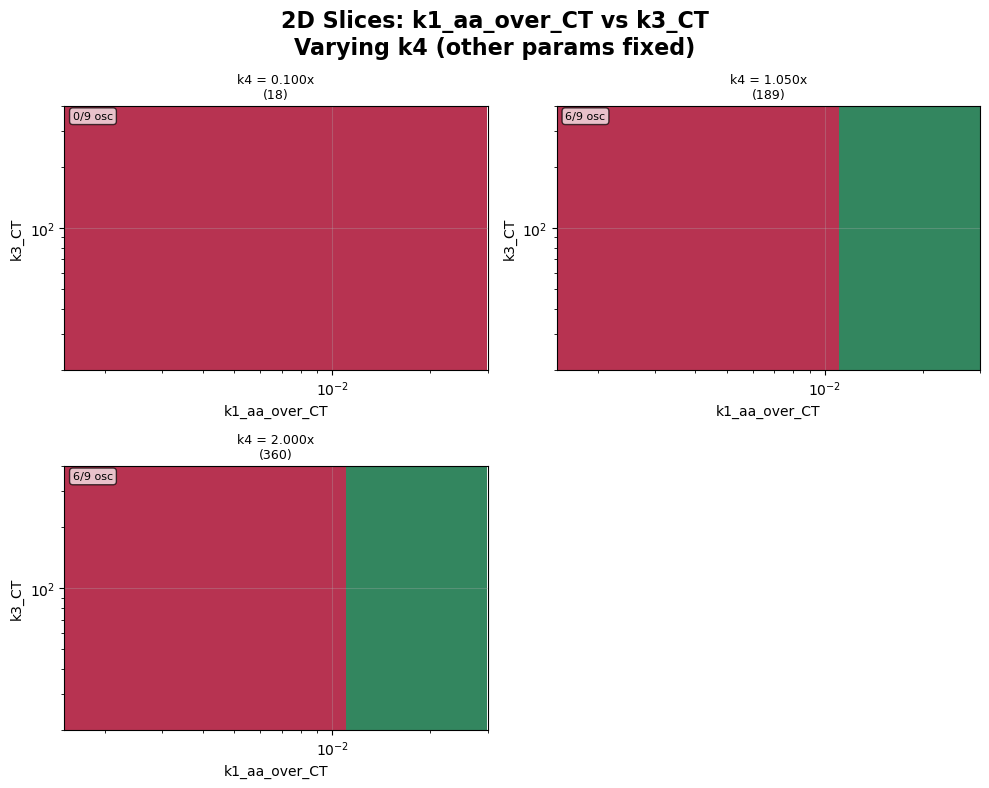


Example 2: k6 vs k7, varying k4


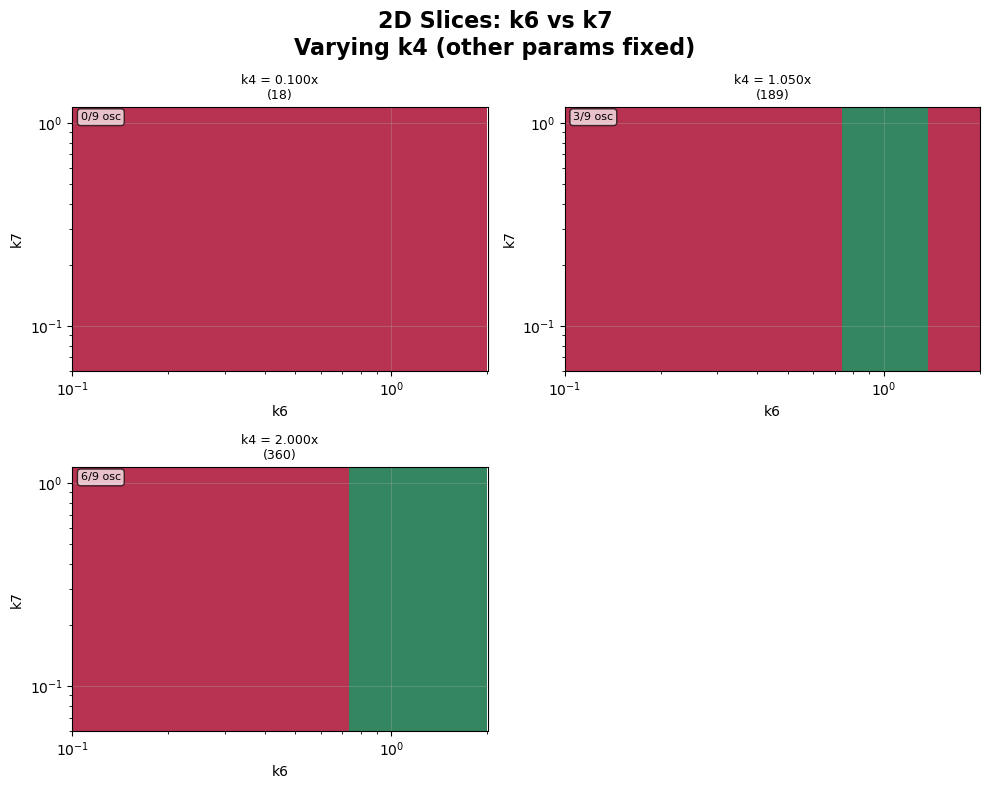


✓ 2D slice visualizations with third parameter iteration complete

To create custom visualizations, use:
  plot_2d_slices_varying_third_param(
      param_names.index('param1'),  # x-axis
      param_names.index('param2'),  # y-axis
      param_names.index('param3'),  # iterate over this
      fixed_at='standard')  # or specify fixed_params={...}


In [ ]:
# ----------------------------
# 2D Slice with Third Parameter Iteration
# (Only for grid sweep, not for random sampling)
# ----------------------------

if RANDOM:
    print("Skipping 2D slice with third parameter iteration (random sampling mode)")
else:
    def plot_2d_slices_varying_third_param(param1_idx, param2_idx, param3_idx, 
                                           fixed_params=None, fixed_at='standard'):
        """
        Plot 2D slices of param1 vs param2, iterating over all values of param3.
        Creates n_steps_per_param plots, one for each value of param3.
        
        Args:
            param1_idx: Index of first parameter to plot (x-axis)
            param2_idx: Index of second parameter to plot (y-axis)
            param3_idx: Index of third parameter to iterate over
            fixed_params: Dict of {param_name: value} for remaining fixed parameters
            fixed_at: 'standard' (use base values) for remaining fixed parameters
        """
        param1_name = param_names[param1_idx]
        param2_name = param_names[param2_idx]
        param3_name = param_names[param3_idx]
        
        # Set up fixed parameters (excluding the three we're varying)
        if fixed_params is None:
            if fixed_at == 'standard':
                fixed_params = {name: p[name] for name in param_names 
                              if name not in [param1_name, param2_name, param3_name]}
            elif fixed_at == 'median_osc' and oscillation_count > 0:
                osc_params = param_values[is_osc_array]
                fixed_params = {name: np.median(osc_params[:, param_names.index(name)]) 
                              for name in param_names 
                              if name not in [param1_name, param2_name, param3_name]}
            else:
                fixed_params = {name: p[name] for name in param_names 
                              if name not in [param1_name, param2_name, param3_name]}
        
        # Create subplots: arrange in a grid
        n_cols = int(np.ceil(np.sqrt(n_steps_per_param)))
        n_rows = int(np.ceil(n_steps_per_param / n_cols))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
        fig.suptitle(f'2D Slices: {param1_name} vs {param2_name}\n'
                     f'Varying {param3_name} (other params fixed)',
                     fontsize=16, fontweight='bold')
        
        if n_steps_per_param == 1:
            axes = np.array([axes])
        axes = axes.flatten()
        
        # Iterate over all values of param3
        for mult_idx, mult_val in enumerate(multipliers):
            ax = axes[mult_idx]
            
            # Create fixed params dict including param3 at this value
            current_fixed = fixed_params.copy()
            current_fixed[param3_name] = p[param3_name] * mult_val
            
            # Create and plot the 2D slice
            try:
                grid, param1_vals, param2_vals = create_2d_slice(
                    param1_idx, param2_idx, fixed_params=current_fixed
                )
                
                # Plot heatmap
                im = ax.imshow(grid, aspect='auto', origin='lower', cmap='RdYlGn', 
                              extent=[param1_vals[0], param1_vals[-1], 
                                     param2_vals[0], param2_vals[-1]],
                              interpolation='nearest', alpha=0.8)
                
                ax.set_xlabel(f'{param1_name}', fontsize=10)
                ax.set_ylabel(f'{param2_name}', fontsize=10)
                ax.set_title(f'{param3_name} = {mult_val:.3f}x\n'
                            f'({p[param3_name] * mult_val:.4g})', fontsize=9)
                ax.set_xscale('log')
                ax.set_yscale('log')
                ax.grid(True, alpha=0.3)
                
                # Count oscillations in this slice
                n_osc = np.sum(grid)
                n_total = grid.size
                ax.text(0.02, 0.98, f'{n_osc}/{n_total} osc', 
                       transform=ax.transAxes, fontsize=8,
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                
            except Exception as e:
                ax.text(0.5, 0.5, f'Error:\n{str(e)[:50]}', ha='center', va='center',
                       fontsize=8, transform=ax.transAxes, color='red')
                ax.axis('off')
        
        # Hide unused subplots
        for idx in range(n_steps_per_param, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        return fig

    # Example usage:
    print("Creating 2D slice visualizations with third parameter iteration...")
    print("\nExample 1: k1 vs k3, varying k4")
    param1_idx = param_names.index('k1_aa_over_CT')
    param2_idx = param_names.index('k3_CT')
    param3_idx = param_names.index('k4')
    plot_2d_slices_varying_third_param(param1_idx, param2_idx, param3_idx, fixed_at='standard')

    print("\nExample 2: k6 vs k7, varying k4")
    param1_idx = param_names.index('k6')
    param2_idx = param_names.index('k7')
    param3_idx = param_names.index('k4')
    plot_2d_slices_varying_third_param(param1_idx, param2_idx, param3_idx, fixed_at='standard')

    print("\n✓ 2D slice visualizations with third parameter iteration complete")
    print("\nTo create custom visualizations, use:")
    print("  plot_2d_slices_varying_third_param(")
    print("      param_names.index('param1'),  # x-axis")
    print("      param_names.index('param2'),  # y-axis")
    print("      param_names.index('param3'),  # iterate over this")
    print("      fixed_at='standard')  # or specify fixed_params={...}")


PARAMETER CORRELATION ANALYSIS

Correlation matrix for oscillatory cases (using multipliers):
Param1               Param2               Correlation     p-value        
----------------------------------------------------------------------
k1_aa_over_CT        k3_CT                       -0.0095      9.1856e-01
k1_aa_over_CT        k4                          -0.2752      2.5600e-03
k1_aa_over_CT        k4prime                      0.1426      1.2351e-01
k1_aa_over_CT        k6                           0.3199      4.1284e-04
k1_aa_over_CT        k7                           0.1299      1.6078e-01
k3_CT                k4                          -0.0100      9.1431e-01
k3_CT                k4prime                     -0.0007      9.9395e-01
k3_CT                k6                           0.0073      9.3766e-01
k3_CT                k7                          -0.0118      8.9879e-01
k4                   k4prime                      0.0023      9.8018e-01
k4                   k6        

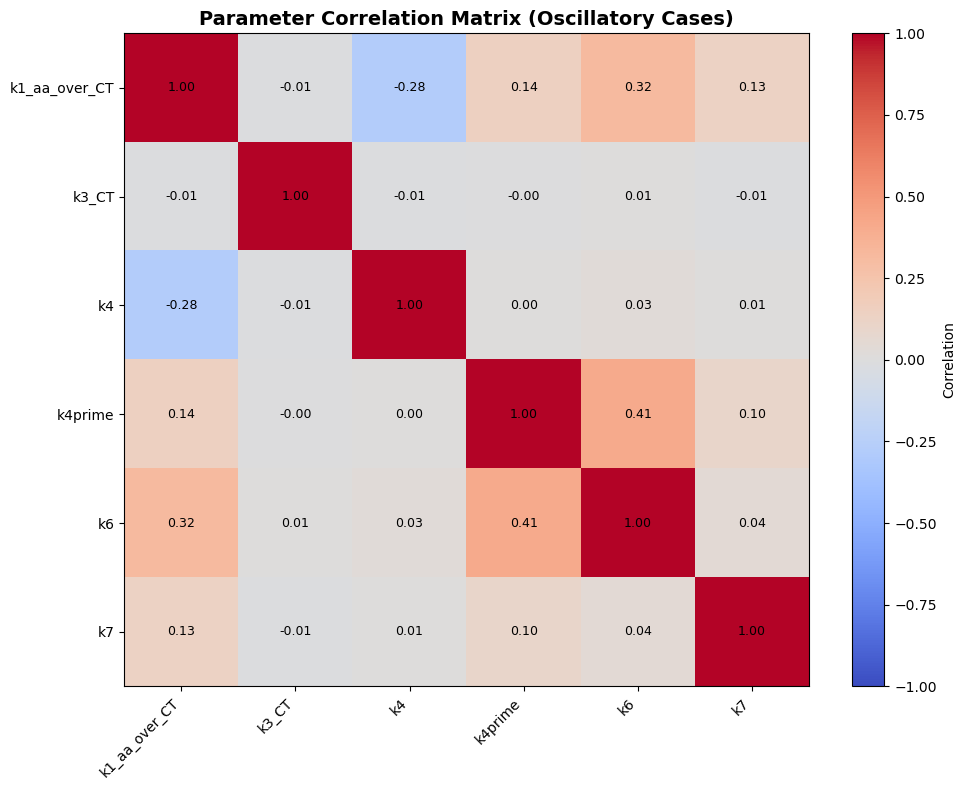


MOST COMMON PARAMETER PATTERNS IN OSCILLATORY CASES

Parameter multiplier distribution in oscillatory cases:

k1_aa_over_CT:
  Multiplier 1.050x: 54 times (45.8%)
  Multiplier 2.000x: 64 times (54.2%)

k3_CT:
  Multiplier 0.100x: 40 times (33.9%)
  Multiplier 1.050x: 39 times (33.1%)
  Multiplier 2.000x: 39 times (33.1%)

k4:
  Multiplier 1.050x: 57 times (48.3%)
  Multiplier 2.000x: 61 times (51.7%)

k4prime:
  Multiplier 0.100x: 36 times (30.5%)
  Multiplier 1.050x: 52 times (44.1%)
  Multiplier 2.000x: 30 times (25.4%)

k6:
  Multiplier 1.050x: 79 times (66.9%)
  Multiplier 2.000x: 39 times (33.1%)

k7:
  Multiplier 0.100x: 30 times (25.4%)
  Multiplier 1.050x: 45 times (38.1%)
  Multiplier 2.000x: 43 times (36.4%)

Analysis complete!


In [ ]:
# ----------------------------
# Additional Analysis: Parameter Correlations and Patterns
# ----------------------------

if oscillation_count > 0:
    print("="*60)
    print("PARAMETER CORRELATION ANALYSIS")
    print("="*60)
    
    # Calculate correlations between parameters in oscillatory cases
    from scipy.stats import pearsonr
    
    osc_params = param_values[is_osc_array]
    osc_multipliers = multipliers_array[is_osc_array]
    
    print(f"\nCorrelation matrix for oscillatory cases (using multipliers):")
    print(f"{'Param1':<20} {'Param2':<20} {'Correlation':<15} {'p-value':<15}")
    print("-" * 70)
    
    correlations = []
    for i in range(len(param_names)):
        for j in range(i+1, len(param_names)):
            corr, pval = pearsonr(osc_multipliers[:, i], osc_multipliers[:, j])
            correlations.append((i, j, corr, pval))
            print(f"{param_names[i]:<20} {param_names[j]:<20} {corr:>14.4f}  {pval:>14.4e}")
    
    # Find strongest correlations
    correlations_sorted = sorted(correlations, key=lambda x: abs(x[2]), reverse=True)
    print(f"\nStrongest correlations (|r| > 0.3):")
    for i, j, corr, pval in correlations_sorted:
        if abs(corr) > 0.3:
            print(f"  {param_names[i]} vs {param_names[j]}: r={corr:.4f}, p={pval:.4e}")
    
    # Visualize correlation matrix
    fig, ax = plt.subplots(figsize=(10, 8))
    corr_matrix = np.corrcoef(osc_multipliers.T)
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(param_names)))
    ax.set_yticks(range(len(param_names)))
    ax.set_xticklabels(param_names, rotation=45, ha='right')
    ax.set_yticklabels(param_names)
    ax.set_title('Parameter Correlation Matrix (Oscillatory Cases)', fontsize=14, fontweight='bold')
    
    # Add correlation values to cells
    for i in range(len(param_names)):
        for j in range(len(param_names)):
            text = ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=9)
    
    plt.colorbar(im, ax=ax, label='Correlation')
    plt.tight_layout()
    plt.show()
    
    # Analysis: Which parameter combinations are most common in oscillatory cases?
    print(f"\n{'='*60}")
    print("MOST COMMON PARAMETER PATTERNS IN OSCILLATORY CASES")
    print(f"{'='*60}")
    
    # Count how often each parameter is at each multiplier level in oscillatory cases
    print(f"\nParameter multiplier distribution in oscillatory cases:")
    for i, name in enumerate(param_names):
        mult_counts = np.bincount([np.argmin(np.abs(multipliers - m)) 
                                   for m in osc_multipliers[:, i]], 
                                  minlength=len(multipliers))
        print(f"\n{name}:")
        for mult_idx, count in enumerate(mult_counts):
            if count > 0:
                pct = 100 * count / len(osc_multipliers)
                print(f"  Multiplier {multipliers[mult_idx]:.3f}x: {count} times ({pct:.1f}%)")
    
    print(f"\n{'='*60}")
    print("Analysis complete!")
    print(f"{'='*60}")
else:
    print("No oscillatory cases found - cannot perform correlation analysis")


In [ ]:
# ----------------------------
# Squared Difference Integral Analysis: Compare each sweep point to p0
# ----------------------------

from scipy.integrate import trapz
import json

print("="*60)
print("SQUARED DIFFERENCE INTEGRAL ANALYSIS")
print("="*60)

# First, simulate with base parameters p0 to get reference trajectory
print("\nSimulating with base parameters p0...")
t_eval = np.linspace(simulation_time_start, simulation_time_end, simulation_time_points)
t0, y0 = simulate_at_params(p, t_eval)
YT0, M0 = compute_obs(y0)

print(f"✓ Reference simulation complete")
print(f"  Time range: {simulation_time_start} to {simulation_time_end}")
print(f"  Time points: {len(t0)}")

# Compute squared difference integrals for each result
print(f"\nComputing squared difference integrals for {len(oscillation_results)} sweep points...")

squared_diff_integrals = []
valid_results = []

for i, result in enumerate(oscillation_results):
    if result['YT'] is not None and result['M'] is not None and result['t'] is not None:
        YT = result['YT']
        M = result['M']
        t = result['t']
        
        # Interpolate reference values to match the time points of this result
        # (in case different simulations have slightly different time points)
        YT0_interp = np.interp(t, t0, YT0)
        M0_interp = np.interp(t, t0, M0)
        
        # Compute squared differences
        diff_YT_sq = (YT - YT0_interp)**2
        diff_M_sq = (M - M0_interp)**2
        
        # Compute integrals using trapezoidal rule
        integral_YT_sq = trapz(diff_YT_sq, t)
        integral_M_sq = trapz(diff_M_sq, t)
        
        # Total squared difference integral (sum of both observables)
        total_squared_diff_integral = integral_YT_sq + integral_M_sq
        
        squared_diff_integrals.append(total_squared_diff_integral)
        valid_results.append({
            'index': i,
            'params': result['params'],
            'is_oscillatory': result['is_oscillatory'],
            'squared_diff_integral': total_squared_diff_integral,
            'integral_YT_sq': integral_YT_sq,
            'integral_M_sq': integral_M_sq
        })
    else:
        # Skip invalid results
        squared_diff_integrals.append(np.nan)

squared_diff_integrals = np.array(squared_diff_integrals)
valid_mask = ~np.isnan(squared_diff_integrals)

print(f"✓ Computed squared difference integrals for {np.sum(valid_mask)} valid results")
print(f"  Mean: {np.mean(squared_diff_integrals[valid_mask]):.6e}")
print(f"  Median: {np.median(squared_diff_integrals[valid_mask]):.6e}")
print(f"  Min: {np.min(squared_diff_integrals[valid_mask]):.6e}")
print(f"  Max: {np.max(squared_diff_integrals[valid_mask]):.6e}")
print(f"  Std: {np.std(squared_diff_integrals[valid_mask]):.6e}")

# Save results to file
output_filename = 'squared_diff_integrals_results.json'
print(f"\nSaving results to {output_filename}...")

# Prepare data for saving (convert numpy types to native Python types)
save_data = {
    'simulation_time_start': float(simulation_time_start),
    'simulation_time_end': float(simulation_time_end),
    'simulation_time_points': int(simulation_time_points),
    'base_parameters': {k: float(v) for k, v in p.items()},
    'total_combinations': int(len(oscillation_results)),
    'valid_results': int(np.sum(valid_mask)),
    'statistics': {
        'mean': float(np.mean(squared_diff_integrals[valid_mask])),
        'median': float(np.median(squared_diff_integrals[valid_mask])),
        'min': float(np.min(squared_diff_integrals[valid_mask])),
        'max': float(np.max(squared_diff_integrals[valid_mask])),
        'std': float(np.std(squared_diff_integrals[valid_mask]))
    },
    'squared_diff_integrals': [float(x) if not np.isnan(x) else None 
                               for x in squared_diff_integrals],
    'results': []
}

# Save detailed results (limit to avoid huge files)
for result in valid_results[:1000]:  # Save first 1000 for space
    save_data['results'].append({
        'index': result['index'],
        'params': {k: float(v) for k, v in result['params'].items()},
        'is_oscillatory': result['is_oscillatory'],
        'squared_diff_integral': float(result['squared_diff_integral']),
        'integral_YT_sq': float(result['integral_YT_sq']),
        'integral_M_sq': float(result['integral_M_sq'])
    })

with open(output_filename, 'w') as f:
    json.dump(save_data, f, indent=2)

print(f"✓ Results saved to {output_filename}")

# Plot distribution
print(f"\nPlotting distribution...")

fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram
n_bins = 50
counts, bins, patches = ax.hist(squared_diff_integrals[valid_mask], bins=n_bins, 
                                edgecolor='black', alpha=0.7, color='steelblue')

# Add vertical line for mean
mean_val = np.mean(squared_diff_integrals[valid_mask])
median_val = np.median(squared_diff_integrals[valid_mask])
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4e}')
ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.4e}')

# Formatting
ax.set_xlabel('Squared Difference Integral', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title(f'Distribution of Squared Difference Integrals\n'
             f'Time sim: {simulation_time_start} to {simulation_time_end} (n={simulation_time_points} points)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Add statistics text box
stats_text = f'Mean: {mean_val:.4e}\n'
stats_text += f'Median: {median_val:.4e}\n'
stats_text += f'Min: {np.min(squared_diff_integrals[valid_mask]):.4e}\n'
stats_text += f'Max: {np.max(squared_diff_integrals[valid_mask]):.4e}\n'
stats_text += f'Std: {np.std(squared_diff_integrals[valid_mask]):.4e}'
ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"✓ Distribution plot complete")
print(f"\n{'='*60}")
print("Squared difference integral analysis complete!")
print(f"{'='*60}")


ImportError: cannot import name 'trapz' from 'scipy.integrate' (/Users/gijsbartholomeus/.local/share/mamba/envs/bioevo/lib/python3.11/site-packages/scipy/integrate/__init__.py)